In [78]:
import yfinance as yf
import random 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

In [79]:
# 1.

goog_data = yf.download('GOOG','2001-01-01', '2018-01-01')


[*********************100%***********************]  1 of 1 completed


In [80]:
# 2.

random.seed(6666)

In [87]:
# 3. 
signals = pd.DataFrame(index = goog_data.index)

In [88]:
# 4. 

signals['signal'] = [random.randint(0,1) for _ in range(len(signals))]

#5. 

signals['orders'] = signals['signal'].diff()

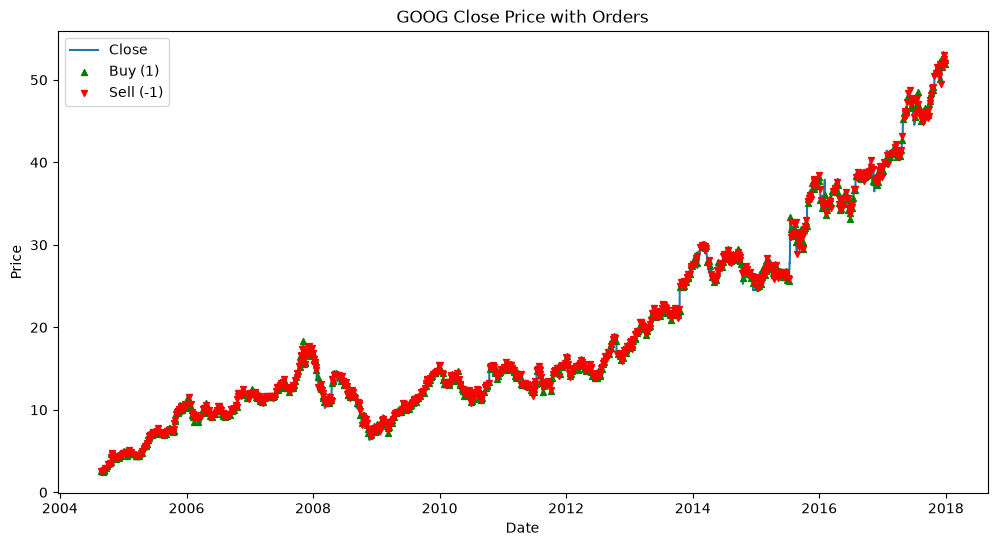

In [ ]:
# 6

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(goog_data['Close'], label='Close')

orders = signals['orders'].fillna(0)
buys = orders == 1
sells = orders == -1

ax.scatter(goog_data.index[buys], goog_data['Close'][buys], color='green', marker='^', s=18, label='Buy (1)', zorder=6)
ax.scatter(goog_data.index[sells], goog_data['Close'][sells], color='red', marker='v', s=18, label='Sell (-1)', zorder=6)

ax.set_title('GOOG Close Price with Orders')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.show()

In [111]:
# 7 

# start with initial capital of $10,000
# display holding value, total value, cash value. 
# these functions calculate change in each value. The main function should calculate change in shares
# first. 

def typ_price(close, low, high) -> int:
    return (close + low + high) / 3

def cash_value(initial: int, order: int, date: pd.Timestamp, ticker_price: pd.DataFrame) -> int:
    '''
    Calculates the cash value of the portfolio for the day.
    '''
    if order == 0:
        return initial
    
    dayta = ticker_price.loc[date]
    day_price = typ_price(dayta['Close', 'GOOG'], dayta['Low', 'GOOG'], dayta['High', 'GOOG'])
    if order == -1: 
        return initial + (day_price * 100)
    elif order == 1:
        return initial - (day_price * 100)


def holding_value(signal: int, date: pd.Timestamp, ticker_price: pd.DataFrame) -> int:
    '''
    Calculates holding value of the portfolio
    '''
    if signal == 0:
        return 0
    else:
        dayta = ticker_price.loc[date]
        day_price = typ_price(dayta['Close', 'GOOG'], dayta['Low', 'GOOG'], dayta['High', 'GOOG'])
        return 100 * day_price

def total_value(cash_value: int, holding_value: int) -> int:
    '''
    Calculates total value of the portfolio
    '''
    
    return cash_value + holding_value

In [113]:
# main function: creates 3 lists, which will then be appended to the portfolio dataframe. 
# FIRST: find change in shares owned, then calculate cash val, holding val, and total val. 
cash_val = [10000]
holding_v = [0]
total_val = [10000]

for i, orders in signals['orders'][1:].items(): # currently, portfolio just has orders.
    new_cash = cash_value(cash_val[-1], orders, i, goog_data)
    cash_val.append(new_cash)

    new_hold = holding_value(signals['signal'].loc[i], i, goog_data)
    holding_v.append(new_hold)

    total_val.append(total_value(new_cash, new_hold))

In [114]:
signals['cash value'] = cash_val
signals['holding value'] = holding_v
signals['total value'] = total_val

In [115]:
display(signals)

,signal,orders,cash value,holding value,total value
Date,,,,,
2004-08-19,0,NaN,10000.000000,0.000000,10000.000000
2004-08-20,0,0.0,10000.000000,0.000000,10000.000000
2004-08-23,0,0.0,10000.000000,0.000000,10000.000000
2004-08-24,1,1.0,9736.618045,263.381955,10000.000000
2004-08-25,1,0.0,9736.618045,261.604282,9998.222327
...,...,...,...,...,...
2017-12-22,0,-1.0,12521.552632,0.000000,12521.552632
2017-12-26,1,1.0,7289.250921,5232.301712,12521.552632
2017-12-27,0,-1.0,12502.933252,0.000000,12502.933252


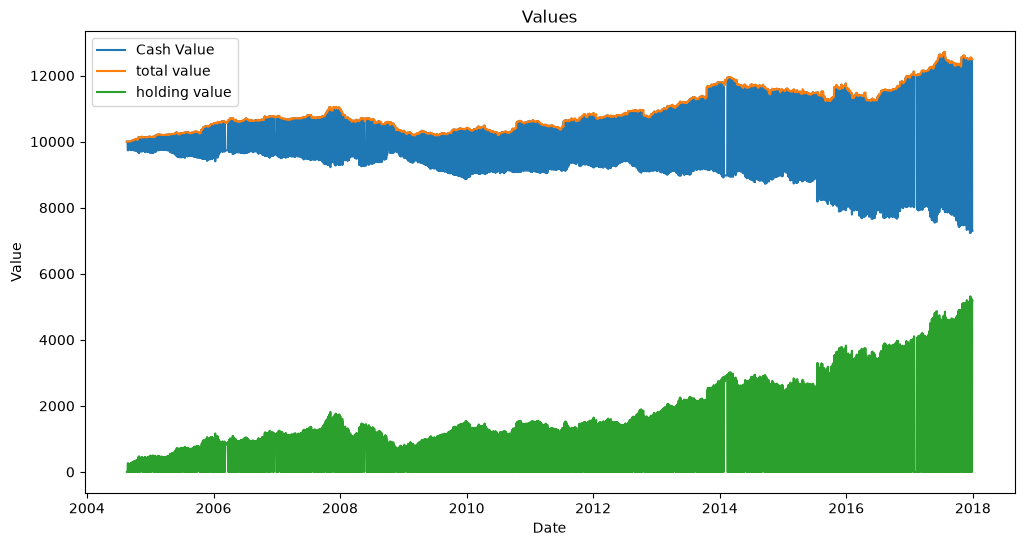

In [116]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(signals['cash value'], label = 'Cash Value')
ax.plot(signals['total value'], label = 'total value')
ax.plot(signals['holding value'], label = 'holding value')

ax.legend()
ax.set_title('Values')
ax.set_xlabel('Date')
ax.set_ylabel('Value')

plt.show()